In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import bezier
import os
import scipy.optimize as opt
import subprocess as sp
xfoilpath = r"D:\Blue Bull\xfoil\xfoil.exe"

In [2]:
class airfoil_structured:
    #класс для хранения данных о профиле с структурированными точками (расстояние между всеми абсциссами одинаковое)
    def __init__(self, r_forw, up_coords, down_coords, lasty = 0, dy_te = 0, min_thick = -1):   
        self.N = len(up_coords) + 3
        self.r_forw = r_forw
        self.dy_te = dy_te
        self.x_coords = np.append([0], np.linspace(0, 1, self.N-1)) #вторая точка должна висеть на нуле и задавать 1) радиус кривизны 2) вертикальность касательной передней кромки 
        self.up_y_coords = np.concatenate(([0, 0], up_coords, [lasty+dy_te/2]))
        self.down_y_coords = np.concatenate(([0, 0], down_coords, [lasty-dy_te/2]))
        D = self.x_coords[2] #там на самом деле сложная формула и с ней можно ознакомиться в папке с материалами, но она упрощается до такого вида
        t = (r_forw*D*(self.N-2)/(self.N-1))**0.5
        self.up_y_coords[1] = t
        self.down_y_coords[1] = -t
        self.update_curve()
        if min_thick != -1: self.correct_thick(min_thick)

    def update_curve(self): 
        """
        Создает объекты двух кривых Безье
        """
        upnodes = np.asfortranarray([self.x_coords, self.up_y_coords])
        downnodes = np.asfortranarray([self.x_coords, self.down_y_coords])
        self.upcurve = bezier.Curve.from_nodes(upnodes)
        self.downcurve = bezier.Curve.from_nodes(downnodes)
        
    def coords(self, Ncoords):
        t_space = np.linspace(0, 1, Ncoords)
        up_coords = self.upcurve.evaluate_multi(t_space)
        down_coords = self.downcurve.evaluate_multi(t_space)
        return up_coords, down_coords
    
    def self_intersect(self):
        if self.dy_te != 0: intersec_num = 1
        else: intersec_num = 2
        intersections = self.upcurve.intersect(self.downcurve)
        return len(intersections[0]) > intersec_num
    
    def plot(self, show_circle = False):
        data = self.coords(100)
        x_coords = np.append(data[0][0], data[1][0][::-1])
        y_coords = np.append(data[0][1], data[1][1][::-1])
        plt.figure(figsize=(9, 5))
        plt.plot(x_coords, y_coords, 'b-', linewidth=2)  
        plt.title(f"Профиль по {(self.N-3)*2+1} параметрам, толщина = {round(self.thick()[0], 2)}%", fontsize=14)
        plt.xlabel("X", fontsize=12)
        plt.ylabel("Y", fontsize=12)
        plt.grid()
        plt.axis('equal')  
        plt.scatter(self.x_coords, self.up_y_coords, color = "black", s=25)
        plt.scatter(self.x_coords, self.down_y_coords, color = "black", s=25)  
        if(show_circle):
            plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)  # Горизонтальная ось
            plt.gca().add_artist(plt.Circle((self.r_forw, 0), radius=self.r_forw, fill = False))
        plt.show()
        
    def create_selig_file(self, N, name = "bezier_airfoil_selig.dat"):
        upper_curve, lower_curve = self.coords(N)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        filename = name
        upper_sorted = sorted(zip(x_upper, y_upper), key=lambda point: point[0], reverse = True)
        lower_sorted = sorted(zip(x_lower, y_lower), key=lambda point: point[0])
        with open(filename, 'w') as f:
            for x, y in upper_sorted:
                f.write(f"{x}   {y}\n")
            for x, y in lower_sorted[1:]:
                f.write(f"{x}   {y}\n")
                
    def create_icem_file(self, N):
        upper_curve, lower_curve = self.coords(N)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        filename = "bezier_airfoil_icem.txt"
        upper_sorted = zip(x_upper, y_upper)
        lower_sorted = zip(x_lower, y_lower)
        with open(filename, 'w') as f:
            f.write(f"{N} 2\n")
            for x, y in upper_sorted:
                f.write(f"{x} {y} 0.0\n")
            for x, y in lower_sorted:
                f.write(f"{x} {y} 0.0\n")
                
    def thick(self):
        upper_curve, lower_curve = self.coords(100)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        x_grid = np.linspace(0, 1, 100)
        upper_y_interp = np.interp(x_grid, x_upper, y_upper)
        lower_y_interp = np.interp(x_grid, x_lower, y_lower)
        thickness = upper_y_interp - lower_y_interp
        max_thick = np.max(thickness)*100
        pos = np.argmax(thickness)
        return max_thick, pos
    
    def correct_thick(self, min_thick):
        thickness, pos = self.thick()
        k = 0
        while thickness < min_thick:
            k += 1
            factor = min_thick / thickness
            for i in range(2, self.N-1):
                self.up_y_coords[i] *= factor
                self.down_y_coords[i] *= factor
            self.update_curve()
            thickness, pos = self.thick()
        
    def elevate(self):
        self.upcurve = self.upcurve.elevate()
        self.downcurve = self.downcurve.elevate()
        self.x_coords, self.up_y_coords = self.upcurve.nodes
        self.down_y_coords = self.downcurve.nodes[1]
        self.N = len(self.x_coords)
            

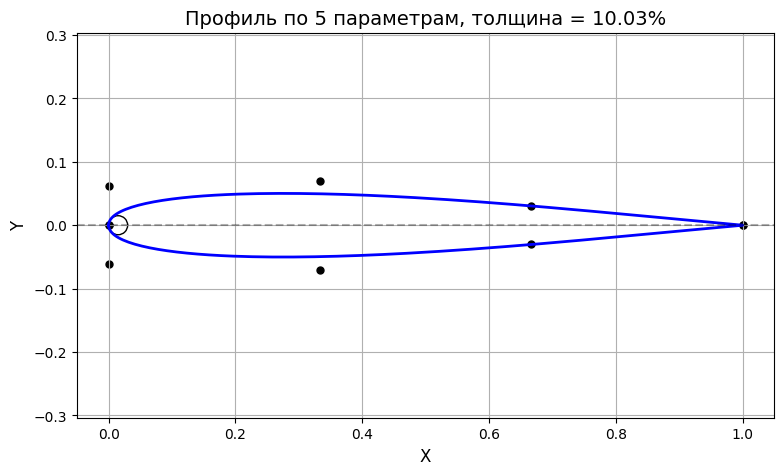

In [3]:
caca0012 = airfoil_structured(0.015, [0.07, 0.03], [-0.07, -0.03], lasty= 0, dy_te = 0, min_thick=-1)
caca0012.plot(show_circle=True)

In [ ]:
def xfoil_optimization(target_cl, target_Re, minclmax, dy_te = 0, min_thick = -1, min_r_forw = 0.01, max_r_forw = 0.1, points = 3):
    def create_airfoil_from_params(params):
        params = np.array(params)/100
        r_forw = params[0]
        if  r_forw < min_r_forw: r_forw = min_r_forw
        up_coords = params[1:points+1]
        down_coords = params[points+1:-1]
        lasty = params[-1]
        airfoil = airfoil_structured(r_forw, up_coords, down_coords, lasty, dy_te, min_thick)
        return airfoil
    
    def Xfoil(name, Ncrit, Re, iter = 100):
        def Cmd(cmd):
            ps.stdin.write(cmd+'\n')
        try:
            os.remove(name+'.log')
        except :
            pass
        ps = sp.Popen(xfoilpath,
              stdin=sp.PIPE,
              stdout=sp.PIPE,
              stderr=None,
              universal_newlines=True, shell=True)
        Cmd('load '+name+'.dat')
        Cmd(' ')
        Cmd('OPER')
        Cmd('Vpar')
        Cmd('N '+str(Ncrit))
        Cmd(' ')
        Cmd('visc '+str(Re))
        Cmd('PACC')
        Cmd(name+'.log')  # output file
        Cmd(' ')          # no dump file
        Cmd(f'iter {iter}')
        Cmd(f"cl {target_cl}")
        Cmd('aseq 9 15 0.5')
        Cmd(' ')     # escape OPER
        Cmd('quit')
        ps.stdout.close()
        ps.stdin.close()
        ps.wait()           
    def objective(params):
        try:
            bez_airfoil = create_airfoil_from_params(params)
            bez_airfoil.create_selig_file(95)
            if bez_airfoil.self_intersect(): return 1000
            Xfoil("bezier_airfoil_selig", Ncrit=5, Re=target_Re)
            filename = "bezier_airfoil_selig.log"
            with open(filename, 'r') as f:
                flines = f.readlines()
            words = flines[12].split()
            cd = float(words[2])
            clmax = 0
            for i in range(12, len(flines)):
                words = flines[i].split()
                cy = float(words[1])
                if cy > clmax:
                    clmax = cy
            penalty = 0
            if clmax < minclmax:
                penalty = (minclmax - clmax)**2
                print(cd+penalty)
            return (cd + penalty)*1000
        except: return 150
    caca0012 = airfoil_structured(0.01, [0.07, 0.03], [-0.07, -0.03], lasty= 0, dy_te = 0, min_thick=-1)
    for i in range(points - 2):
        caca0012.elevate()
    params = [caca0012.r_forw*100] + list(caca0012.up_y_coords[2:-1]*100) + list(caca0012.down_y_coords[2:-1]*100) + [caca0012.up_y_coords[-1]*100]
    first_bound = (min_r_forw*100, max_r_forw*100)
    rest_bounds = [(None, None)] * (len(params) - 1)
    my_bounds = [first_bound] + rest_bounds
    #optimized_params = opt.minimize(objective, params, method='Nelder-Mead', bounds = my_bounds, options = {'disp': True, "adaptive": True})
    #optimized_params = opt.minimize(objective, params, method='BFGS', bounds = my_bounds, options={'eps': 1e-2, 'disp': True})
    optimized_params = opt.basinhopping(objective, params, niter=3, stepsize = 0.3, minimizer_kwargs={'method': 'Nelder-Mead', 'bounds': my_bounds},disp=True)
    optimized_airfoil = create_airfoil_from_params(optimized_params.x)
    optimized_airfoil.create_selig_file(70, name="optimized_airfoil.dat")
    Xfoil("optimized_airfoil", Ncrit=9, Re=target_Re)
    return optimized_airfoil

In [ ]:
optimized_airfoil = xfoil_optimization(target_cl=0.4, target_Re=250000, minclmax=1.3, dy_te=0, min_thick=9, min_r_forw=0.011, max_r_forw = 0.013, points=8)
optimized_airfoil.plot(show_circle=True)

c:\Users\vova1\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_basinhopping.py:298: OptimizeWarning: Initial guess is not within the specified bounds
  return self.minimizer(self.func, x0, **self.kwargs)


0.12126249
0.12835744000000004
0.11238584000000003
0.11883984000000003
0.13418264000000002
0.12126249
0.12120636000000001
0.12213400000000005
0.12165969000000001
0.12007521000000004
0.12068804000000007
0.12161344000000003
0.12180225000000001
0.12240976000000002
0.12184225000000001
0.12199489


In [ ]:
optimized_airfoil.create_selig_file(75, name = "ch13.dat")

In [ ]:
print(optimized_airfoil.r_forw)

0.011120522080151019
